# Pandas for Data Analysis

In [1]:
import numpy as np
import pandas as pd

## Pandas Series and Dataframe

A series is essentially a column and a dataframe is multidimensional table made up of collection of series.

### How to create pandas series

In [2]:
gender = pd.Series(["Male", "Female", "Female", "Female", "Male", "Male", "Female", "Female", "Female", "Male", "Male"])
gender

0       Male
1     Female
2     Female
3     Female
4       Male
5       Male
6     Female
7     Female
8     Female
9       Male
10      Male
dtype: object

In [3]:
type(gender)

pandas.core.series.Series

In [4]:
country = pd.Series(["Nigeria", "Ethiopia", "Cameroon", "Ghana", "Kenya", "Uganda", "Kenya", "Ethiopia", "Cameroon", "Ghana"])
country

0     Nigeria
1    Ethiopia
2    Cameroon
3       Ghana
4       Kenya
5      Uganda
6       Kenya
7    Ethiopia
8    Cameroon
9       Ghana
dtype: object

In [5]:
type(country)

pandas.core.series.Series

In [6]:
age = pd.Series([16, 18, 17,19,20,15,17,14,18,17])
age

0    16
1    18
2    17
3    19
4    20
5    15
6    17
7    14
8    18
9    17
dtype: int64

The indexes of a Series can be manually set also.

In [7]:
age = pd.Series(
    [16, 18, 17,19,20,15,17,14,18,17],
    index = [1,2,3,4,5,6,7,8,9,10]
    )
age

1     16
2     18
3     17
4     19
5     20
6     15
7     17
8     14
9     18
10    17
dtype: int64

In [8]:
age = pd.Series(
    [16, 18, 17,19,20,15,17,14,18,17],
    index = ["jan","Ifechi","c","d","e","f","g","h","i","j"]
    )
age

jan       16
Ifechi    18
c         17
d         19
e         20
f         15
g         17
h         14
i         18
j         17
dtype: int64

### How to create Pandas Dataframe

To create a dataframe, we simply create a data dictionary. That is; the variable will become a key and a list containing the values of the variables becomes the value for the key. then the dictionary is passed into pd.DataFrame() method.

In [9]:
registration_dict = {
    "gender": ["Male", "Female", "Female", "Male", "Male", "Female", "Female", "Female", "Male", "Male"],
    "country": ["Nigeria", "Ethiopia", "Cameroon", "Ghana", "Kenya", "Uganda", "Kenya", "Ethiopia", "Cameroon", "Ghana"],
    "age": [16, 18, 17,19,20,15,17,14,18,17]
}
registration_dict

{'gender': ['Male',
  'Female',
  'Female',
  'Male',
  'Male',
  'Female',
  'Female',
  'Female',
  'Male',
  'Male'],
 'country': ['Nigeria',
  'Ethiopia',
  'Cameroon',
  'Ghana',
  'Kenya',
  'Uganda',
  'Kenya',
  'Ethiopia',
  'Cameroon',
  'Ghana'],
 'age': [16, 18, 17, 19, 20, 15, 17, 14, 18, 17]}

In [10]:
registration_df = pd.DataFrame(registration_dict)
registration_df

,gender,country,age
0,Male,Nigeria,16
1,Female,Ethiopia,18
2,Female,Cameroon,17
3,Male,Ghana,19
4,Male,Kenya,20
5,Female,Uganda,15
6,Female,Kenya,17
7,Female,Ethiopia,14
8,Male,Cameroon,18
9,Male,Ghana,17


The resulting DataFrame will have it's index assigned automatically as with Series and the columns are placed unordered. If you specify a sequence of columns, the DataFrame's columns will be arranged in that order.

In [11]:
registration_df = pd.DataFrame(registration_dict, columns = ["gender", "age", "country"])
registration_df

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


Excercise: Using the below excel data, create a DataFrame.

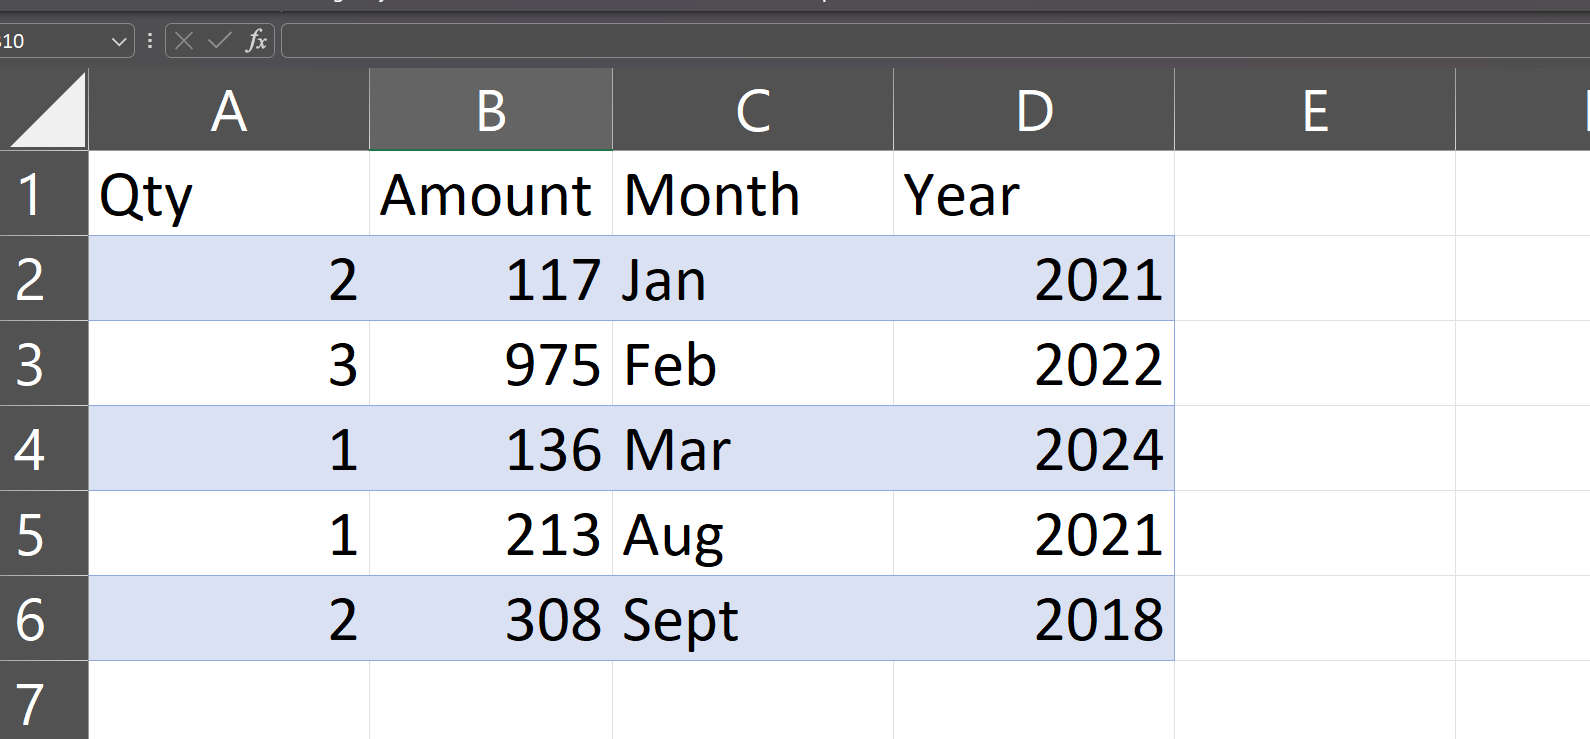

In [12]:
ex_dict = {
    "Qty": [2,3,1,1,2],
    "Amount": [117,975,136,213,308],
    "Month":["Jan", "Feb", "Mar", "Aug", "Sept"],
    "Year": [2021, 2022,2024,2021,2018]
}
exercise_df = pd.DataFrame(ex_dict)

## Attributes and Methods of DataFrame

### .head()
gives the first 5 rows

In [13]:
registration_df.head(5)

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya


### .info()
gives the structure of the DataFrame

In [14]:
registration_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   gender   10 non-null     object
 1   age      10 non-null     int64 
 2   country  10 non-null     object
dtypes: int64(1), object(2)
memory usage: 372.0+ bytes


### .shape
outputs just a tuple of (rows, columns)

In [15]:
registration_df.shape

(10, 3)

### .index and .columns
used to see the the list of observations and column names in our df.

In [16]:
registration_df.index

RangeIndex(start=0, stop=10, step=1)

In [17]:
registration_df.columns

Index(['gender', 'age', 'country'], dtype='object')

## Selection and Indexing of Dataframe 

A column in a DataFrame can be retrieved as a Series

In [18]:
registration_df["country"] 

#OR

registration_df.country

0     Nigeria
1    Ethiopia
2    Cameroon
3       Ghana
4       Kenya
5      Uganda
6       Kenya
7    Ethiopia
8    Cameroon
9       Ghana
Name: country, dtype: object

Note that the df.column_name will fail when the varable name has special character like the "space character".  

To select two or more columns, we pass the list of the columns into the into the indexing

In [19]:
registration_df[['age', 'country', "gender"]]

,age,country,gender
0,16,Nigeria,Male
1,18,Ethiopia,Female
2,17,Cameroon,Female
3,19,Ghana,Male
4,20,Kenya,Male
5,15,Uganda,Female
6,17,Kenya,Female
7,14,Ethiopia,Female
8,18,Cameroon,Male
9,17,Ghana,Male


### ``.loc[]`` and ``iloc[]``
The ``.loc[]`` and ``iloc[]`` DataFrame attribute enable you to select a subset of the rows and columns from a DataFrame with NumPy-like notation using either axis labels (``df.loc[]``) or integers (``df.iloc[]``). The general format for both ``.loc[]`` and ``.iloc[]`` are ``df.loc[row, col]`` and ``iloc[row, col]`` where ``df`` is the name of the DataFrame while ``[row, col] specifies the row and column index of the DataFrame. Remember, Python counting starts at 0, so the first row is row zero

### ``.loc[row, col]``
Here the rows to extract is passed as ``a:b`` while the columns is specified by a list.

In [20]:
registration_df.loc[0:3, ["country", "age"]]

,country,age
0,Nigeria,16
1,Ethiopia,18
2,Cameroon,17
3,Ghana,19


In [21]:
registration_df.loc[0:5:2, ["country", "age"]]


,country,age
0,Nigeria,16
2,Cameroon,17
4,Kenya,20


Please not that ``.loc`` index position is inclusive. i.e 0:5 means 0,1,2,3,4,5. This is different from numpy array that have 0:5 as 0,1,2,3,4

In [22]:
registration_df.loc[5:8, ["gender"]]

,gender
5,Female
6,Female
7,Female
8,Male


In [23]:
registration_df.loc[6:, ["gender"]]

,gender
6,Female
7,Female
8,Male
9,Male


### ```.iloc[]```


In [24]:
registration_df.iloc[0:5, [0,1]]
# or
registration_df.iloc[0:5, 0:2]

,gender,age
0,Male,16
1,Female,18
2,Female,17
3,Male,19
4,Male,20


In [25]:
exercise_df

,Qty,Amount,Month,Year
0,2,117,Jan,2021
1,3,975,Feb,2022
2,1,136,Mar,2024
3,1,213,Aug,2021
4,2,308,Sept,2018


## Class work 2: From the exercise_df,
* Print out the shape
* print out the first 3 rows
* using ``iloc[]``, print out the df below

In [26]:
iloc_df

NameError: name 'iloc_df' is not defined

* using ``loc[]`` print out the first 3 rows of "Month" and "Year" column

## How to rename column in DataFrame

We use ``.rename`` method to rename certain or all columns in a DataFrame via a dict.

In [ ]:
registration_df

In [ ]:
# registration_df.rename(columns=
#     {
#         "country": "COUNTRY",
#         "gender": "GENDER"
#     }
# )

# OR

registration_df.rename(
    {
        "country": "Country",
        "gender": "Gender"
    },
    axis = "columns"
)

In [ ]:
registration_df = registration_df.rename(
    {
        "country": "Country",
        "gender": "Gender"
    },
    axis = "columns"
)

In [ ]:
registration_df.rename(columns=
    {
        "country": "COUNTRY",
        "gender": "GENDER"
    }, inplace = True
)

In [ ]:
registration_df

In [ ]:
registration_df.rename(str.lower, axis='columns', inplace = True)

In [ ]:
registration_df.rename(str.upper, axis='columns', inplace  = True)

In [ ]:
registration_df

In [ ]:
registration_df.rename(str.lower, axis='columns', inplace  = True)

In [ ]:
registration_df

In [ ]:
registration_df.rename({"GENDER":"SEX"}, axis='columns')

In [ ]:
registration_df.rename({1:2, 2:4}, axis='index')

In [ ]:
registration_df

## Adding Variables (Columns) to the DataFrame

In [ ]:
registration_df["age_plus_5"] = registration_df["age"]+5

In [ ]:
registration_df

## Dropping/ removing Variables (Columns) from the DataFrame

``.drop()`` method is used to drop column(s) from a particular df.

In [ ]:
registration_df

In [ ]:
registration_df.columns

In [ ]:
# registration_df.drop(['age_plus_5', 'country'], axis="columns")

# Or

# registration_df.drop(columns=["age_plus_5"])

# registration_df.drop(['age_plus_5', 'country'], axis="columns")

In [ ]:
registration_df.drop('age_plus_5', axis="columns", inplace = True)

# Or

# registration_df.drop(columns="age_plus_5", inplace=True)

In [ ]:
registration_df

## Conditional Filtering of a DataFrame

In [ ]:
# First is to create a Boolean Mask
registration_df["gender"] == "Female"

In [ ]:
# Then pass the boolean mask into the df indexer
registration_df[registration_df["gender"]=="Female"]

## How to import data with pandas

From the previous examples, we can see that it is so tedious to start creating DataFrame from scratch. ...  

The first thing in importing generally is to know your working directory

### Importing a csv

ls - list the files in the working directory
pwd - print working directory
cd - change working directory

In [ ]:
pwd

In [ ]:
ls

In [ ]:
cd datasets

In [ ]:
ls

In [ ]:
ls

**Absolute referencing**

### Importing Excel file

In [ ]:
pd.read_excel(file_path)

### Importing a JSON file

In [ ]:
pd.read_json(file_path)

## Exporting Data with Pandas

```python
df.to_csv(file_path)
df.to_excel(file_path)
df.to_json(file_path)
```

In [ ]:
df = pd.read_csv("datasets/mexico-city-real-estate-1.csv")

In [ ]:
df.head(2)

In [ ]:
df.shape

In [ ]:
df.info()

## Evaluation

1. filter all the rows whose property type is "apartment". Save it as "apartment_df". Display the first 3 rows
   
3. in the "apartment_df", drop the variables "property_type" and "property_url".

In [ ]:
df.hea

In [ ]:
df.head(3)

In [ ]:
df["operation"].nunique()   #Count number of distinct elements in specified axis.

In [ ]:
df["operation"].unique()   # Returns an array of distinct elements

In [ ]:
df["property_type"].nunique()   #Count number of distinct elements in specified axis.

In [ ]:
df["property_type"].unique()

In [ ]:
df["place_with_parent_names"].unique()

In [ ]:
df.head(3)

In [ ]:
df["lat-lon"].info()

In [ ]:
df["lat-lon"].str.split(",", expand = True).astype(float).head()

In [ ]:
df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand = True).astype(float)

In [ ]:
df.head(2)

In [ ]:
df.drop("lat-lon", axis = 1, inplace = True)

In [ ]:
df.head(2)

In [ ]:
df.info()

In [ ]:
df.drop(columns = ["floor",	"rooms",	"expenses",	"properati_url"], inplace = True)

In [ ]:
df["price_in_usd"] = df["price"]*0.058

In [ ]:
df.head(2)

## **Sorting by in Pandas**

In Pandas, sorting a DataFrame is done using: ``.sort_values()`` method

```python
df.sort_values()
```

### Sort by One Column

The column is passed as a string into df.sort_values()
```python
df.sort_values("column")
```

In [27]:
registration_df.sort_values("age").head()

,gender,age,country
7,Female,14,Ethiopia
5,Female,15,Uganda
0,Male,16,Nigeria
2,Female,17,Cameroon
6,Female,17,Kenya


In [28]:
registration_df.sort_values("age", ascending = False).head()

,gender,age,country
4,Male,20,Kenya
3,Male,19,Ghana
8,Male,18,Cameroon
1,Female,18,Ethiopia
9,Male,17,Ghana


## Sorting by multiple columns

The columns is passed as a list into the method; .sort_values()
```python
df.sort_values(["column1", "column2", ...])
```

In [29]:
registration_df.sort_values(["gender", "country", "age"]).head()

,gender,age,country
2,Female,17,Cameroon
7,Female,14,Ethiopia
1,Female,18,Ethiopia
6,Female,17,Kenya
5,Female,15,Uganda


In [30]:
registration_df.sort_values(
    ["gender", "country", "age"],
    ascending =[False, True, False]
).reset_index(drop=True)

,gender,age,country
0,Male,18,Cameroon
1,Male,19,Ghana
2,Male,17,Ghana
3,Male,20,Kenya
4,Male,16,Nigeria
5,Female,17,Cameroon
6,Female,18,Ethiopia
7,Female,14,Ethiopia
8,Female,17,Kenya
9,Female,15,Uganda


## Sorting by index

In [31]:
df.sort_index()
df.sort_index(ascending=False)

NameError: name 'df' is not defined

## GROUP BY in Pandas

In [32]:
registration_df[["department","salary"]] = pd.DataFrame(
    {
        "department":["IT", "HR", "IT", "HR", "Finance", "ML", "Finance", "IT","ML","ML"],
        "salary":[200, 300, 250, 320,220,230,290,240,400,350]
    }
)

In [33]:
registration_df.head()

,gender,age,country,department,salary
0,Male,16,Nigeria,IT,200
1,Female,18,Ethiopia,HR,300
2,Female,17,Cameroon,IT,250
3,Male,19,Ghana,HR,320
4,Male,20,Kenya,Finance,220


In [39]:
registration_df.groupby("department")["salary"].mean().round()

department
Finance    255.0
HR         310.0
IT         230.0
ML         327.0
Name: salary, dtype: float64

In [45]:
registration_df.groupby("department")["salary"].agg(["sum", "mean", "count", 'max', 'min']).round()

,sum,mean,count,max,min
department,,,,,
Finance,510,255.0,2,290,220
HR,620,310.0,2,320,300
IT,690,230.0,3,250,200
ML,980,327.0,3,400,230


In [ ]:
# Note that the .reset_index() is so important